<a href="https://colab.research.google.com/github/Lando8/2026-ML-DL/blob/main/result.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 부품 성능에 따른 핸드폰 가격 정도 예측

- 사용한 데이터 : Mobile Price Classification

: https://www.kaggle.com/datasets/iabhishekofficial/mobile-price-classification

핸드폰 안에 있는 성능을 통해 정확한 가격 수치가 아닌 가격 정도를 분류한 데이터셋

가격이 더 높게 예측될수록 높은 숫자로 예측
(0~3)

### 1. 데이터셋 준비

예측해야하는 값은 price_range로, [0,1,2,3]의 값으로 이루어져 있다.

classification을 진행할 때 logistic regression같이 binery classification으로 진행해야 하는 경우에는

0,1 > 0 / 2,3, > 1

으로 나눠서 진행할 예정이다.

In [ ]:
from sklearn import datasets
X = df.drop(columns=['price_range', 'price'])
y = df['price_range']

y_dict = {0:0,1:1,2:2,3:3}

print(X.shape, y.shape)
import itertools
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings(action='ignore')


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

url = "https://raw.githubusercontent.com/Lando8/2026-ML-DL/main/data/phone_price/train.csv"

df = pd.read_csv(url)

print(df.price_range.unique())
df['price'] = df.price_range.map({0:0, 1:0, 2:1, 3:1})

df.head()

# price를 만들어 binary classification 진행
# closed_from 존재 x > gradient descent 사용


### 1. Logistic Regression

ML/DL Lab 1 강의를 보고 제작하였다.

- binary classification
- z = Xw + b로 linear function 계산
- sigmoid를 사용하여 0~1 확률로 변환
- gradient descent로 weight, bias 업데이트
- 0.5를 기준으로 0 / 1 classification

In [18]:
# closed_from 존재 x > gradient descent 사용

class LogisticRegression:
  def __init__ (self, learning_rate=0.01, n_iterations=1000):
    self.learning_rate = learning_rate
    self.n_iterations = n_iterations
    self.weights = None
    self.bias = None

  def sigmoid(self,z):
    return 1 / (1+ np.exp(-z))

  def fit(self, X,y) :
    n_samples, n_features = X.shape
    self.weights = np.zeros(n_features)
    self.bias = 0

    for _ in range(self.n_iterations):
        linear_model = np.dot(X, self.weights) + self.bias
        # linear하게 만든 뒤 확률적으로 해석이 가능하게 시그모이드로 변환
        y_predicted = self.sigmoid(linear_model)

        dw = (1 / n_samples) * np.dot(X.T, (y_predicted - y))
        db = (1 / n_samples) * np.sum(y_predicted - y)

        self.weights -= self.learning_rate * dw
        self.bias -= self.learning_rate * db

  def predict(self, X):
    linear_model = np.dot(X, self.weights) + self.bias
    y_predicted = self.sigmoid(linear_model)

    y_predicted_cls = [1 if i > 0.5 else 0 for i in y_predicted]

    return np.array(y_predicted_cls)

def accuracy(y_true, y_pred):
    accuracy = sum(1 for true, pred in zip(y_true, y_pred) if true == pred)
    return accuracy / len(y_true)

X = df.drop(columns=['price_range', 'price'])
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

Logistic regression으로 classification을 진행할 시 정확도가 0.76이 나옴을 확인할 수 있다.

In [20]:
model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(accuracy(y_test, y_pred))

0.76


### 2. LDA (Linear Discriminant Analysis)

Lab 1 강의를 보고 제작하였다.

각각의 class별로 나누는 것이 가능하기 때문에 class는 0~3 으로 진행하였다.

- Gaussian distribution 가정
- class들이 shared variance를 가진다고 가정
- 각 class의 mean, variance, prior probability 계산
- 각 class별 discriminant score 계산
- score가 가장 높은 class로 classification

In [21]:
from sklearn import datasets
X = df.drop(columns=['price_range', 'price'])
y = df['price_range']
print(X.shape, y.shape)

# X는 20개의 column이 있는 2000개짜리 데이터
# y는 0,1,2,3으로 나누어진 정답 데이터

(2000, 20) (2000,)


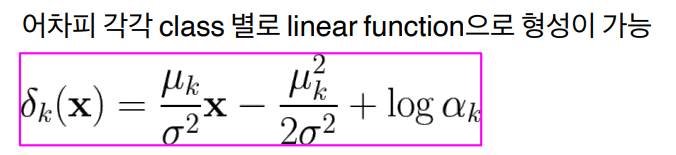

In [22]:
n_classes = len(np.unique(y))
n_features = X.shape[1]

# mean vectors for each class
# 각 class의 평균  feature가 들어있음
mean_vectors = np.array([
    X[y == k].mean(axis=0)
    for k in range(n_classes)
])
# shared variance (assumed equal across classes)
S_W = np.zeros((n_features, n_features))
for k in range (n_classes):
    class_scatter = np.cov(X[y==k], rowvar = False, bias = True)
    S_W += class_scatter

# average variance across all classes
shared_variance = np.mean(np.diag(S_W))

# prior probabilities for each class
class_priors = np.array([np.mean(y == k) for k in range(n_classes)])

# discriminant function
def discriminant_function(x) :
  discriminant_scores = (mean_vectors.dot(x.T) / shared_variance -
                         (np.sum(mean_vectors**2,axis = 1) / (2*shared_variance)) +
                         np.log(class_priors))
  return np.argmax(discriminant_scores)
pred = np.apply_along_axis(discriminant_function, 1, X) # 각 행에 적용

accuracy = np.mean(pred == y)
print(f"accuracy: {accuracy}")

accuracy: 0.797


LDA로 classification을 진행해 정확도가 0.797이 나오는 것을 확인하였다.

### 3. Decision Tree

In [57]:
X = df.drop(columns=['price_range', 'price'])
y = df['price_range']

# 1. Train + Validation / Test 분리
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 2. Train / Validation 분리
# 남은 80% 중 25%를 validation으로 사용
# >> Train 60%, Validation 20%, Test 20%
# class의 비율을 같게 하기 위해서 stratify 사용
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.25,
    random_state=42,
    stratify=y_train_val
)

# 크기 확인
print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)


# 직접 구현한 DecisionTree에서 numpy indexing을 사용하므로 변환
X_train = X_train.to_numpy()
X_val = X_val.to_numpy()
X_test = X_test.to_numpy()

Train: (1200, 20) (1200,)
Validation: (400, 20) (400,)
Test: (400, 20) (400,)


In [51]:
class DecisionTree:
    def __init__(self, min_samples=None):
        self.min_samples = min_samples

    def fit(self, X, y):
        self.tree = self._grow_tree(X, y)

    def _grow_tree(self, X, y, depth=0):
        # Stopping criteria
        n_labels = len(np.unique(y))

        if (self.min_samples is not None and len(y) <= self.min_samples) or n_labels == 1:
            return np.argmax(np.bincount(y))

        # tree를 나누기에 최적인 지점을 구한 뒤 나눈다.
        feature_idx, threshold = self._best_split(X, y)

        left_indices = X[:, feature_idx] < threshold
        X_left, y_left = X[left_indices], y[left_indices]
        X_right, y_right = X[~left_indices], y[~left_indices]

        # Recursively grow the tree
        # 이후 재반복해 하위 트리를 만든다.
        left_tree = self._grow_tree(X_left, y_left, depth + 1)
        right_tree = self._grow_tree(X_right, y_right, depth + 1)

        return [feature_idx, threshold, left_tree, right_tree]

    # 모든 경우 중에서 entropy가 가장 작은 feature + threshold를 찾는다
    def _best_split(self, X, y):
        n_features = X.shape[1]

        best_feature_idx = None
        best_threshold = None
        min_entropy = float('inf')

        for feature_idx in range(n_features):

            # 현재 feature에 존재하는 unique value
            thresholds = np.unique(X[:, feature_idx])

            for threshold in thresholds:

                y_left = y[X[:, feature_idx] < threshold]
                y_right = y[X[:, feature_idx] >= threshold]

                if len(y_left) == 0 or len(y_right) == 0:
                    continue

                entropy = self._entropy(y_left, y_right)

                if entropy < min_entropy:
                    best_feature_idx, best_threshold, min_entropy = (
                        feature_idx,
                        threshold,
                        entropy
                    )

        return best_feature_idx, best_threshold

    def _entropy(self, y_left, y_right):
        n_left, n_right = len(y_left), len(y_right)
        n_total = n_left + n_right

        p_left = np.unique(y_left, return_counts=True)[1] / n_left
        p_right = np.unique(y_right, return_counts=True)[1] / n_right

        entropy_left = -np.sum(p_left * np.log(p_left))
        entropy_right = -np.sum(p_right * np.log(p_right))

        return (n_left / n_total) * entropy_left + \
               (n_right / n_total) * entropy_right

    def predict(self, X):
        return np.array([self._predict(x, self.tree) for x in X])

    def _predict(self, x, tree):
        if not isinstance(tree, list):
            return tree

        feature_idx, threshold, left_tree, right_tree = tree

        if x[feature_idx] < threshold:
            return self._predict(x, left_tree)
        else:
            return self._predict(x, right_tree)

In [52]:
# Decision Tree 학습
dt = DecisionTree(min_samples=5)
dt.fit(X_train, y_train)

# Validation set 예측
y_val_pred = dt.predict(X_val)

# Validation accuracy
dt_val_accuracy = np.mean(y_val_pred == y_val)

print("Val set accuracy:", dt_val_accuracy)


Val set accuracy: 0.835


### 4. Random forest

원리는 decision tree와 거의 비슷하며
특정 feature만 랜덤하게 추출한다는 점이 다르다.

In [61]:
X = df.drop(columns=['price_range', 'price'])
y = df['price_range']

# 1. Train + Validation / Test 분리
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 2. Train / Validation 분리
# 남은 80% 중 25%를 validation으로 사용
# >> Train 60%, Validation 20%, Test 20%
# class의 비율을 같게 하기 위해서 stratify 사용
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.25,
    random_state=42,
    stratify=y_train_val
)

# 크기 확인
print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

X_train = X_train.to_numpy()
X_val = X_val.to_numpy()
X_test = X_test.to_numpy()

y_train = y_train.to_numpy()
y_val = y_val.to_numpy()
y_test = y_test.to_numpy()


Train: (1200, 20) (1200,)
Validation: (400, 20) (400,)
Test: (400, 20) (400,)


In [58]:
class DecisionTreeForRF:
    def __init__(self, min_samples=None):
        self.min_samples = min_samples

    def fit(self, X, y):
        self.tree = self._grow_tree(X, y)

    def _grow_tree(self, X, y, depth=0):
        # Stopping criteria
        n_labels = len(np.unique(y))

        if (self.min_samples is not None and len(y) <= self.min_samples) or n_labels == 1:
            return np.argmax(np.bincount(y))

        # Find the best split
        feature_idx, threshold = self._best_split_with_random(X, y)

        # split 가능한 지점이 없으면 현재 class 중 가장 많은 값 반환
        if feature_idx is None:
            return np.argmax(np.bincount(y))

        left_indices = X[:, feature_idx] < threshold

        X_left, y_left = X[left_indices], y[left_indices]
        X_right, y_right = X[~left_indices], y[~left_indices]

        # All samples end up in the same side
        if len(X_left) == 0 or len(X_right) == 0:
            return np.argmax(np.bincount(y))

        # Recursively grow the tree
        left_tree = self._grow_tree(X_left, y_left, depth + 1)
        right_tree = self._grow_tree(X_right, y_right, depth + 1)

        return [feature_idx, threshold, left_tree, right_tree]

    def _best_split_with_random(self, X, y):
        n_features = X.shape[1]

        best_feature_idx = None
        best_threshold = None
        min_entropy = float('inf')

        # 전체 feature 중 sqrt(n_features)개를 랜덤 선택
        features = np.random.choice(
            n_features,
            int(np.sqrt(n_features)),
            replace=False
        )

        for feature_idx in features:

            thresholds = np.unique(X[:, feature_idx])

            for threshold in thresholds:

                y_left = y[X[:, feature_idx] < threshold]
                y_right = y[X[:, feature_idx] >= threshold]

                # 빈 split은 건너뛰기
                if len(y_left) == 0 or len(y_right) == 0:
                    continue

                entropy = self._entropy(y_left, y_right)

                if entropy < min_entropy:
                    best_feature_idx, best_threshold, min_entropy = (
                        feature_idx,
                        threshold,
                        entropy
                    )

        return best_feature_idx, best_threshold

    def _entropy(self, y_left, y_right):
        n_left, n_right = len(y_left), len(y_right)
        n_total = n_left + n_right

        p_left = np.unique(y_left, return_counts=True)[1] / n_left
        p_right = np.unique(y_right, return_counts=True)[1] / n_right

        entropy_left = -np.sum(p_left * np.log(p_left))
        entropy_right = -np.sum(p_right * np.log(p_right))

        return (
            (n_left / n_total) * entropy_left
            + (n_right / n_total) * entropy_right
        )

    def predict(self, X):
        return np.array([
            self._predict(x, self.tree)
            for x in X
        ])

    def _predict(self, x, tree):
        if not isinstance(tree, list):
            return tree

        feature_idx, threshold, left_tree, right_tree = tree

        if x[feature_idx] < threshold:
            return self._predict(x, left_tree)
        else:
            return self._predict(x, right_tree)

In [59]:
class RandomForestClassifier:
    def __init__(self, n_trees=100, min_samples=5):
        self.n_trees = n_trees
        self.min_samples = min_samples

    def fit(self, X, y):
        self.trees = [
            DecisionTreeForRF(min_samples=self.min_samples)
            for _ in range(self.n_trees)
        ]

        for tree in self.trees:
            # Bootstrap Sampling
            indices = np.random.choice(
                len(X),
                size=len(X),
                replace=True
            )

            tree.fit(X[indices], y[indices])

    def predict(self, X):
        predictions = np.stack(
            [tree.predict(X) for tree in self.trees],
            axis=1
        )

        # 각 tree의 결과 중 가장 많이 나온 class 선택
        return np.array([
            np.argmax(np.bincount(pred))
            for pred in predictions
        ])

In [62]:
rf = RandomForestClassifier(
    n_trees=100,
    min_samples=5
)

rf.fit(X_train, y_train)

y_val_pred = rf.predict(X_val)

rf_val_accuracy = np.mean(y_val_pred == y_val)

print("RF Val set accuracy:", rf_val_accuracy)

RF Val set accuracy: 0.85


### 5.AdaBoost

In [65]:
X = df.drop(columns=['price_range', 'price'])
y = df['price'].map({0:-1,1:1})

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train = X_train.to_numpy()
X_test = X_test.to_numpy()

y_train = y_train.to_numpy()
y_test = y_test.to_numpy()

In [66]:
class DecisionTreeBinaryClassifier:
    def __init__(self, max_depth=None):
        self.max_depth = max_depth

    def fit(self, X, y):
        self.tree = self._grow_tree(X, y)

    def _grow_tree(self, X, y, depth=0):
        # Stopping criteria
        n_labels = len(np.unique(y))

        if (self.max_depth is not None and depth >= self.max_depth) or n_labels == 1:
            return self._majority_class(y)

        # Find the best split
        feature_idx, threshold = self._best_split(X, y)

        # 더 이상 나눌 수 없는 경우
        if feature_idx is None:
            return self._majority_class(y)

        left_indices = X[:, feature_idx] < threshold

        X_left, y_left = X[left_indices], y[left_indices]
        X_right, y_right = X[~left_indices], y[~left_indices]

        # 한쪽이 비어있으면 종료
        if len(y_left) == 0 or len(y_right) == 0:
            return self._majority_class(y)

        # Recursively grow the tree
        left_tree = self._grow_tree(X_left, y_left, depth + 1)
        right_tree = self._grow_tree(X_right, y_right, depth + 1)

        return [feature_idx, threshold, left_tree, right_tree]

    def _majority_class(self, y):
        # -1과 +1 중 더 많은 class 반환
        if np.sum(y == 1) >= np.sum(y == -1):
            return 1
        else:
            return -1

    def _best_split(self, X, y):
        n_features = X.shape[1]

        best_feature_idx = None
        best_threshold = None
        min_entropy = float('inf')

        for feature_idx in range(n_features):

            thresholds = np.unique(X[:, feature_idx])

            for threshold in thresholds:

                y_left = y[X[:, feature_idx] < threshold]
                y_right = y[X[:, feature_idx] >= threshold]

                # 빈 split 건너뛰기
                if len(y_left) == 0 or len(y_right) == 0:
                    continue

                entropy = self._entropy(y_left, y_right)

                if entropy < min_entropy:
                    best_feature_idx = feature_idx
                    best_threshold = threshold
                    min_entropy = entropy

        return best_feature_idx, best_threshold

    def _entropy(self, y_left, y_right):
        n_left, n_right = len(y_left), len(y_right)
        n_total = n_left + n_right

        p_left = np.unique(
            y_left,
            return_counts=True
        )[1] / n_left

        p_right = np.unique(
            y_right,
            return_counts=True
        )[1] / n_right

        entropy_left = -np.sum(p_left * np.log(p_left))
        entropy_right = -np.sum(p_right * np.log(p_right))

        return (
            (n_left / n_total) * entropy_left
            + (n_right / n_total) * entropy_right
        )

    def predict(self, X):
        return np.array([
            self._predict(x, self.tree)
            for x in X
        ])

    def _predict(self, x, tree):
        if not isinstance(tree, list):
            return tree

        feature_idx, threshold, left_tree, right_tree = tree

        if x[feature_idx] < threshold:
            return self._predict(x, left_tree)
        else:
            return self._predict(x, right_tree)

In [67]:
class AdaBoost:
    def __init__(self, n_estimators=100):
        self.n_estimators = n_estimators
        self.models = []

    def fit(self, X, y):
        n_samples = len(X)

        # 처음에는 모든 sample의 weight를 동일하게 설정
        weights = np.full(n_samples, 1 / n_samples)

        self.models = []

        for _ in range(self.n_estimators):

            # weight가 큰 sample이 더 자주 뽑힘
            indices = np.random.choice(
                n_samples,
                size=n_samples,
                replace=True,
                p=weights
            )

            # AdaBoost에서는 깊이 1인 약한 tree 사용
            model = DecisionTreeBinaryClassifier(max_depth=1)

            model.fit(
                X[indices],
                y[indices]
            )

            # 전체 train data에 대해 예측
            y_pred = model.predict(X)

            # weighted error
            error_rate = np.sum(
                weights * (y != y_pred)
            )

            # 0으로 나누는 문제 방지
            error_rate = np.clip(error_rate,1e-10,1 - 1e-10)

            # weak learner의 중요도
            alpha = 0.5 * np.log((1 - error_rate) / error_rate)

            # 틀린 sample의 weight 증가
            # 맞은 sample의 weight 감소
            weights *= np.exp(-alpha * y * y_pred)

            # weight의 합을 다시 1로 맞춤
            weights /= np.sum(weights)

            self.models.append((alpha, model))

    def predict(self, X):

        # 각 weak learner의 예측에 alpha를 곱해서 합산
        final_score = np.zeros(len(X))

        for alpha, model in self.models:
            final_score += alpha * model.predict(X)

        # 최종적으로 -1 / +1 결정
        return np.where(final_score >= 0,1,-1)


In [68]:
adaboost = AdaBoost(n_estimators=100)

adaboost.fit(
    X_train,
    y_train
)

y_pred = adaboost.predict(X_test)

accuracy = np.mean(
    y_pred == y_test
)

print("AdaBoost Accuracy:", accuracy)

AdaBoost Accuracy: 0.955
